In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score

from sklearn.preprocessing import OneHotEncoder

from sklearn.compose import ColumnTransformer

from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge

from sklearn.tree import DecisionTreeRegressor

from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

In [25]:
df = pd.read_csv("Steel_energy_consumption_engineered.csv")

df.head(10)

,date,Usage_kWh,Lagging_Current_Reactive.Power_kVarh,Leading_Current_Reactive_Power_kVarh,CO2(tCO2),Lagging_Current_Power_Factor,Leading_Current_Power_Factor,NSM,WeekStatus,Day_of_week,Load_Type,Hour,Day_of_Week,Month,Weekend,Power_Factor_Ratio,High_Load
0,1/1/2018 0:15,3.17,2.95,0.0,0.0,73.21,100.0,900,Weekday,Monday,Light_Load,0,Monday,January,Weekday,1.365934,0
1,1/1/2018 0:30,4.00,4.46,0.0,0.0,66.77,100.0,1800,Weekday,Monday,Light_Load,0,Monday,January,Weekday,1.497679,0
2,1/1/2018 0:45,3.24,3.28,0.0,0.0,70.28,100.0,2700,Weekday,Monday,Light_Load,0,Monday,January,Weekday,1.422880,0
3,1/1/2018 1:00,3.31,3.56,0.0,0.0,68.09,100.0,3600,Weekday,Monday,Light_Load,1,Monday,January,Weekday,1.468644,0
4,1/1/2018 1:15,3.82,4.50,0.0,0.0,64.72,100.0,4500,Weekday,Monday,Light_Load,1,Monday,January,Weekday,1.545117,0
5,1/1/2018 1:30,3.28,3.56,0.0,0.0,67.76,100.0,5400,Weekday,Monday,Light_Load,1,Monday,January,Weekday,1.475797,0
6,1/1/2018 1:45,3.60,4.14,0.0,0.0,65.62,100.0,6300,Weekday,Monday,Light_Load,1,Monday,January,Weekday,1.523926,0
7,1/1/2018 2:00,3.60,4.28,0.0,0.0,64.37,100.0,7200,Weekday,Monday,Light_Load,2,Monday,January,Weekday,1.553519,0
8,1/1/2018 2:15,3.28,3.64,0.0,0.0,66.94,100.0,8100,Weekday,Monday,Light_Load,2,Monday,January,Weekday,1.493875,0
9,1/1/2018 2:30,3.78,4.72,0.0,0.0,62.51,100.0,9000,Weekday,Monday,Light_Load,2,Monday,January,Weekday,1.599744,0


In [11]:
print(df.shape)

df.info()

df.head()

(35040, 17)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35040 entries, 0 to 35039
Data columns (total 17 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   date                                  35040 non-null  object 
 1   Usage_kWh                             35040 non-null  float64
 2   Lagging_Current_Reactive.Power_kVarh  35040 non-null  float64
 3   Leading_Current_Reactive_Power_kVarh  35040 non-null  float64
 4   CO2(tCO2)                             35040 non-null  float64
 5   Lagging_Current_Power_Factor          35040 non-null  float64
 6   Leading_Current_Power_Factor          35040 non-null  float64
 7   NSM                                   35040 non-null  int64  
 8   WeekStatus                            35040 non-null  object 
 9   Day_of_week                           35040 non-null  object 
 10  Load_Type                             35040 non-null  object 
 11  Hou

,date,Usage_kWh,Lagging_Current_Reactive.Power_kVarh,Leading_Current_Reactive_Power_kVarh,CO2(tCO2),Lagging_Current_Power_Factor,Leading_Current_Power_Factor,NSM,WeekStatus,Day_of_week,Load_Type,Hour,Day_of_Week,Month,Weekend,Power_Factor_Ratio,High_Load
0,1/1/2018 0:15,3.17,2.95,0.0,0.0,73.21,100.0,900,Weekday,Monday,Light_Load,0,Monday,January,Weekday,1.365934,0
1,1/1/2018 0:30,4.00,4.46,0.0,0.0,66.77,100.0,1800,Weekday,Monday,Light_Load,0,Monday,January,Weekday,1.497679,0
2,1/1/2018 0:45,3.24,3.28,0.0,0.0,70.28,100.0,2700,Weekday,Monday,Light_Load,0,Monday,January,Weekday,1.422880,0
3,1/1/2018 1:00,3.31,3.56,0.0,0.0,68.09,100.0,3600,Weekday,Monday,Light_Load,1,Monday,January,Weekday,1.468644,0
4,1/1/2018 1:15,3.82,4.50,0.0,0.0,64.72,100.0,4500,Weekday,Monday,Light_Load,1,Monday,January,Weekday,1.545117,0


In [4]:
df = df.drop(columns=["date", "High_Load"])

In [5]:
X = df.drop("Usage_kWh", axis=1)

y = df["Usage_kWh"]


In [12]:
categorical_columns = X.select_dtypes(include="object").columns

print(categorical_columns)

Index(['WeekStatus', 'Day_of_week', 'Load_Type', 'Day_of_Week', 'Month',
       'Weekend'],
      dtype='object')


In [13]:
preprocessor = ColumnTransformer(

    transformers=[

        ("cat",
         OneHotEncoder(handle_unknown="ignore"),
         categorical_columns)

    ],

    remainder="passthrough"

)

In [14]:
X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,

    test_size=0.20,

    random_state=42

)

In [15]:
models = {

    "Linear Regression": LinearRegression(),

    "Ridge Regression": Ridge(),

    "Decision Tree": DecisionTreeRegressor(random_state=42),

    "Random Forest": RandomForestRegressor(
        random_state=42
    )

}

In [16]:
results = []

for name, model in models.items():

    pipeline = Pipeline([

        ("preprocessor", preprocessor),

        ("model", model)

    ])

    pipeline.fit(X_train, y_train)

    predictions = pipeline.predict(X_test)

    mae = mean_absolute_error(y_test, predictions)

    rmse = np.sqrt(mean_squared_error(y_test, predictions))

    r2 = r2_score(y_test, predictions)

    results.append([

        name,

        mae,

        rmse,

        r2

    ])

    print("="*50)

    print(name)

    print("MAE :", mae)

    print("RMSE:", rmse)

    print("R² :", r2)

Linear Regression
MAE : 5.713517354164248
RMSE: 8.176981379991885
R² : 0.9411791056925428
Ridge Regression
MAE : 4.3988679036189815
RMSE: 6.3308395983045145
R² : 0.9647411432971528
Decision Tree
MAE : 0.5682106164383561
RMSE: 1.4647663234864772
R² : 0.998112520260163
Random Forest
MAE : 0.36359180936072966
RMSE: 1.0735528864183694
R² : 0.9989861061390185


In [17]:
results_df = pd.DataFrame(

    results,

    columns=[

        "Model",

        "MAE",

        "RMSE",

        "R2"

    ]

)

results_df

,Model,MAE,RMSE,R2
0,Linear Regression,5.713517,8.176981,0.941179
1,Ridge Regression,4.398868,6.330840,0.964741
2,Decision Tree,0.568211,1.464766,0.998113
3,Random Forest,0.363592,1.073553,0.998986


In [18]:
cv_scores = []

for name, model in models.items():

    pipeline = Pipeline([

        ("preprocessor", preprocessor),

        ("model", model)

    ])

    score = cross_val_score(

        pipeline,

        X,

        y,

        cv=5,

        scoring="neg_root_mean_squared_error"

    )

    rmse = -score.mean()

    cv_scores.append([

        name,

        rmse

    ])

    print(name)

    print("Mean RMSE:", rmse)

    print()

Linear Regression
Mean RMSE: 8.865517324618231

Ridge Regression
Mean RMSE: 6.893103483165648

Decision Tree
Mean RMSE: 2.6468730903578543

Random Forest
Mean RMSE: 2.260963129214491



In [19]:
cv_df = pd.DataFrame(

    cv_scores,

    columns=[

        "Model",

        "Cross Validation RMSE"

    ]

)

cv_df

,Model,Cross Validation RMSE
0,Linear Regression,8.865517
1,Ridge Regression,6.893103
2,Decision Tree,2.646873
3,Random Forest,2.260963


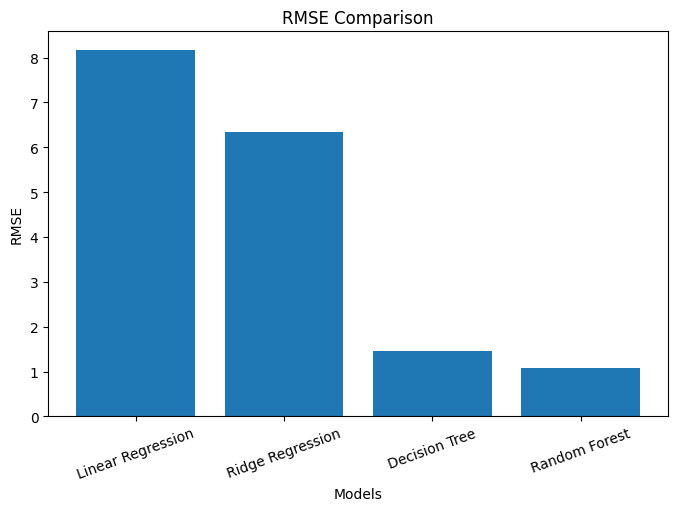

In [20]:
plt.figure(figsize=(8,5))

plt.bar(

    results_df["Model"],

    results_df["RMSE"]

)

plt.title("RMSE Comparison")

plt.xlabel("Models")

plt.ylabel("RMSE")

plt.xticks(rotation=20)

plt.show()

In [21]:
best_model_name = results_df.sort_values(

    by="RMSE"

).iloc[0]["Model"]

print("Best Model:")

print(best_model_name)

Best Model:
Random Forest


In [22]:
best_model = models[best_model_name]

pipeline = Pipeline([

    ("preprocessor", preprocessor),

    ("model", best_model)

])

pipeline.fit(

    X_train,

    y_train

)

predictions = pipeline.predict(

    X_test

)

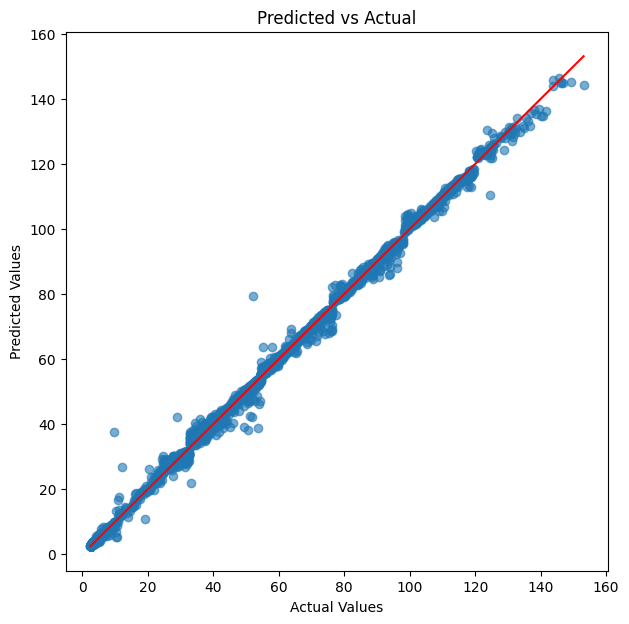

In [23]:
plt.figure(figsize=(7,7))

plt.scatter(

    y_test,

    predictions,

    alpha=0.6

)

plt.plot(

    [y_test.min(), y_test.max()],

    [y_test.min(), y_test.max()],

    color="red"

)

plt.xlabel("Actual Values")

plt.ylabel("Predicted Values")

plt.title("Predicted vs Actual")

plt.show()

In [24]:
print("Model Performance")

print(results_df)

print()

print("Cross Validation Results")

print(cv_df)

Model Performance
               Model       MAE      RMSE        R2
0  Linear Regression  5.713517  8.176981  0.941179
1   Ridge Regression  4.398868  6.330840  0.964741
2      Decision Tree  0.568211  1.464766  0.998113
3      Random Forest  0.363592  1.073553  0.998986

Cross Validation Results
               Model  Cross Validation RMSE
0  Linear Regression               8.865517
1   Ridge Regression               6.893103
2      Decision Tree               2.646873
3      Random Forest               2.260963
